# LLM Prompt vs. PopBERT Expert Coders – Agreement Comparison

This notebook rates a sample of 500 PopBERT gold-standard texts with an LLM
system prompt and compares the results against human expert annotators using
the same metrics reported in the PopBERT paper (Fleiss' κ, Agreement %, pairwise F1).

**Dimension mapping:**
- `people_score > 0` → **People-Centrism** (1/0)
- `elite_score < 0` → **Anti-Elitism** (1/0)

The prompt does not cover Left/Right ideology, so those dimensions are
compared using expert-coder baselines only.

## 1 — Setup & Imports

In [1]:
import json
import os
import time
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.metrics import cohen_kappa_score, f1_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300})

## 2 — Load PopBERT Gold-Standard Data

In [2]:
df_raw = pd.read_csv("data/full.csv.zip")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Coders:  {df_raw['username'].unique()}")
print(f"Unique texts: {df_raw['id'].nunique()}")
df_raw.head(6)

Shape: (43975, 7)
Columns: ['id', 'text', 'username', 'elite', 'centr', 'left', 'right']
Coders:  <StringArray>
['riedel', 'richter', 'grabsch', 'schadt', 'coudry']
Length: 5, dtype: str
Unique texts: 8795


,id,text,username,elite,centr,left,right
0,446633,Ihre willkürliche Zusammenstellung und Auflist...,riedel,True,False,False,False
1,446633,Ihre willkürliche Zusammenstellung und Auflist...,richter,False,False,False,False
2,446633,Ihre willkürliche Zusammenstellung und Auflist...,grabsch,False,False,False,False
3,119028,Einen ganz herzlichen Dank an diese Kolleginne...,schadt,False,False,False,False
4,119028,Einen ganz herzlichen Dank an diese Kolleginne...,coudry,False,False,False,False
5,119028,Einen ganz herzlichen Dank an diese Kolleginne...,grabsch,False,False,False,False


## 3 — Column Mapping & Gold-Standard Extraction

Long format: one row per (text × coder), boolean columns `elite`, `centr`, `left`, `right`.
Pivot to wide matrices, derive gold standard via majority vote.

In [3]:
TEXT_COL = "text"
ID_COL   = "id"

DIM_MAP = {
    "elite": "anti_elitism",
    "centr": "people_centrism",
    "left":  "left_ideology",
    "right": "right_ideology",
}

LABEL_DIMENSIONS = list(DIM_MAP.values())

# The two dimensions our prompt can evaluate
LLM_DIMENSIONS = ["anti_elitism", "people_centrism"]

DISPLAY_NAMES = {
    "anti_elitism":    "Anti-Elitism",
    "people_centrism": "People-Centrism",
    "left_ideology":   "Left-Wing Ideology",
    "right_ideology":  "Right-Wing Ideology",
}

### 3a — Pivot to coder matrices & majority-vote gold standard

In [4]:
gold_matrices = {}
gold_standard = {}

for csv_col, dim_name in DIM_MAP.items():
    wide = df_raw.pivot_table(
        index=ID_COL, columns="username", values=csv_col, aggfunc="first",
    ).astype(float)
    gold_matrices[dim_name] = wide
    gold_standard[dim_name] = (wide.mean(axis=1) >= 0.5).astype(int)

texts = df_raw.drop_duplicates(subset=ID_COL).set_index(ID_COL)[[TEXT_COL]]

print(f"Unique texts: {len(texts)}")
print(f"Coders: {list(gold_matrices['anti_elitism'].columns)}")
for dim_name in LABEL_DIMENSIONS:
    gs = gold_standard[dim_name]
    n_pos = gs.sum()
    print(f"{DISPLAY_NAMES[dim_name]:>22s}:  N_pos={n_pos:5d} / {len(gs)}  "
          f"({100*n_pos/len(gs):.1f}%)")

Unique texts: 8795
Coders: ['coudry', 'grabsch', 'richter', 'riedel', 'schadt']
          Anti-Elitism:  N_pos= 1340 / 8795  (15.2%)
       People-Centrism:  N_pos=  281 / 8795  (3.2%)
    Left-Wing Ideology:  N_pos=  384 / 8795  (4.4%)
   Right-Wing Ideology:  N_pos=  173 / 8795  (2.0%)


## 4 — Expert-Coder Agreement (PopBERT baseline)

In [5]:
popbert_baseline = pd.DataFrame([
    {"Label": "Anti-Elitism",       "N": 3236, "fleiss_kappa": 0.410,
     "agree": 65.80, "F1": 0.496},
    {"Label": "People-Centrism",    "N": 1608, "fleiss_kappa": 0.244,
     "agree": 81.80, "F1": 0.262},
    {"Label": "Left-Wing Ideology", "N": 1393, "fleiss_kappa": 0.355,
     "agree": 84.50, "F1": 0.378},
    {"Label": "Right-Wing Ideology","N":  773, "fleiss_kappa": 0.364,
     "agree": 91.60, "F1": 0.383},
])
popbert_baseline

,Label,N,fleiss_kappa,agree,F1
0,Anti-Elitism,3236,0.410,65.8,0.496
1,People-Centrism,1608,0.244,81.8,0.262
2,Left-Wing Ideology,1393,0.355,84.5,0.378
3,Right-Wing Ideology,773,0.364,91.6,0.383


### 4a — Recompute expert-coder metrics from raw data

In [6]:
def pairwise_f1(mat_df):
    scores = []
    for i, j in combinations(mat_df.columns, 2):
        mask = mat_df[[i, j]].notna().all(axis=1)
        if mask.sum() == 0:
            continue
        scores.append(f1_score(
            mat_df.loc[mask, i].astype(int),
            mat_df.loc[mask, j].astype(int),
            average="binary",
        ))
    return np.mean(scores) if scores else np.nan


def compute_agreement_metrics(mat_df):
    mat = mat_df.dropna().to_numpy().astype(int)
    table, _ = aggregate_raters(mat)
    kappa = fleiss_kappa(table, method="fleiss")
    agree = np.mean(mat.std(axis=1) == 0) * 100
    f1 = pairwise_f1(mat_df.dropna())
    return round(kappa, 3), round(agree, 2), round(f1, 3)


print(f"{'Dimension':>22s}  {'κ':>7s}  {'Agree%':>7s}  {'F1':>6s}")
print("-" * 50)
for dim_name in LABEL_DIMENSIONS:
    kappa, agree, f1 = compute_agreement_metrics(gold_matrices[dim_name])
    print(f"{DISPLAY_NAMES[dim_name]:>22s}  {kappa:7.3f}  {agree:6.2f}%  {f1:.3f}")

             Dimension        κ   Agree%      F1
--------------------------------------------------
          Anti-Elitism    0.410   65.79%  0.496
       People-Centrism    0.244   81.84%  0.262
    Left-Wing Ideology    0.355   84.47%  0.378
   Right-Wing Ideology    0.364   91.59%  0.383


## 5 — Load System Prompt & Configure LLM API

Prompt is sent directly as user message concatenated with the text.
The model returns JSON with `people_score`, `elite_score`, `antagonism_score`
plus explanation fields. We extract and binarize:
- `people_score > 0` → People-Centrism = 1
- `elite_score < 0` → Anti-Elitism = 1

In [7]:
with open("prompt-populism4.md", "r", encoding="utf-8") as f:
    PROMPT_RAW = f.read()

print(f"Prompt length: {len(PROMPT_RAW)} chars")
print(PROMPT_RAW[:500], "\n...")

Prompt length: 12975 chars
You are a political sociology analyst trained to detect populist rhetorical strategies in social media posts. Your goal is to identify which posts contain dimensions of populist attitudes — without judging political views.

Analyze each post holistically. Avoid speculation.

---

### Pre-Analysis Check
Before analyzing, ask: **Does this text carry a detectable rhetorical signal** — through language, symbols, or clear implication?

If you find no signal at all (e.g., only user mentions, hashtags, 
...


In [8]:
API_BASE_URL  = "https://llm.scads.ai/v1"
API_KEY       = open(os.path.join("/home/thhaase/Documents/synosys_internship", "scadsaillm.txt"), "r").readline().strip()
MODEL_NAME    = "Qwen/Qwen3-Coder-30B-A3B-Instruct"
SLEEP_SECONDS = 2
BATCH_SAVE_EVERY = 50

client = OpenAI(base_url=API_BASE_URL, api_key=API_KEY)

In [9]:
def build_messages(text: str) -> list[dict]:
    """Concatenate prompt + text as a single user message."""
    return [
        {"role": "user", "content": PROMPT_RAW + "\n\n" + text}
    ]


def parse_llm_response(answer: str) -> dict | None:
    """Extract JSON object from LLM response."""
    answer = answer.strip()
    if answer.startswith("```"):
        answer = answer.split("\n", 1)[-1].rsplit("```", 1)[0]
    try:
        start = answer.index("{")
        end   = answer.rindex("}") + 1
        return json.loads(answer[start:end])
    except (json.JSONDecodeError, ValueError):
        return None


def binarize_response(parsed: dict) -> dict:
    """
    Convert continuous prompt scores to binary PopBERT labels.
      people_score > 0  →  people_centrism = 1
      elite_score  < 0  →  anti_elitism    = 1
    """
    people = float(parsed.get("people_score", 0))
    elite  = float(parsed.get("elite_score", 0))
    return {
        "anti_elitism":    int(elite < 0),
        "people_centrism": int(people > 0),
        # Also store raw scores for inspection
        "people_score_raw": people,
        "elite_score_raw":  elite,
        "antagonism_score_raw": float(parsed.get("antagonism_score", 0)),
    }

## 6 — Sample 300 Texts & Rate via LLM

Draw a random sample of 300 unique texts, send each to the API,
parse and binarize the response. Checkpointed to `llm_predictions.csv`.

In [10]:
SAMPLE_N = 300

# Build a joint stratification frame from gold-standard labels
strat = pd.DataFrame({
    dim: gold_standard[dim] for dim in LLM_DIMENSIONS
})

# Create a combined stratum key (e.g. "0_1", "1_0", …)
strat["stratum"] = (
    strat["anti_elitism"].astype(str) + "_" + strat["people_centrism"].astype(str)
)

# Compute population proportions per stratum
stratum_props = strat["stratum"].value_counts(normalize=True)
stratum_counts = (stratum_props * SAMPLE_N).round().astype(int)

# Adjust rounding so total equals SAMPLE_N exactly
diff = SAMPLE_N - stratum_counts.sum()
if diff != 0:
    # Add/subtract from the largest stratum
    stratum_counts[stratum_counts.idxmax()] += diff

print("Target stratum counts:")
for s, n in stratum_counts.items():
    ae, pc = s.split("_")
    print(f"  Anti-Elitism={ae}, People-Centrism={pc}: {n}")

# Draw stratified sample
sample_ids = (
    strat.groupby("stratum", group_keys=False)
    .apply(lambda g: g.sample(
        n=min(stratum_counts[g.name], len(g)),
        random_state=42,
    ))
    .index
)

texts_to_rate = texts.loc[sample_ids]
print(f"\nSampled {len(texts_to_rate)} unique texts for rating.")

# Verify: gold-standard distribution in the sample
for dim_name in LLM_DIMENSIONS:
    gs_sample = gold_standard[dim_name].loc[sample_ids]
    print(f"  {DISPLAY_NAMES[dim_name]:>22s}: {gs_sample.sum():3d} positive "
          f"({100*gs_sample.mean():.1f}%)")

Target stratum counts:
  Anti-Elitism=0, People-Centrism=0: 246
  Anti-Elitism=1, People-Centrism=0: 45
  Anti-Elitism=0, People-Centrism=1: 9
  Anti-Elitism=1, People-Centrism=1: 0

Sampled 300 unique texts for rating.
            Anti-Elitism:  45 positive (15.0%)
         People-Centrism:   9 positive (3.0%)


In [11]:
CHECKPOINT_PATH = "data/llm_predictions3.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_done = pd.read_csv(CHECKPOINT_PATH)
    done_ids = set(df_done[ID_COL])
    print(f"Resuming: {len(done_ids)} already rated.")
else:
    df_done = pd.DataFrame()
    done_ids = set()

todo = texts_to_rate.loc[~texts_to_rate.index.isin(done_ids)]
print(f"Remaining: {len(todo)}")

Resuming: 300 already rated.
Remaining: 0


Execute next CELL

In [12]:
results = []
errors = 0

for row in texts_to_rate.reset_index().itertuples():
    prompt = PROMPT_RAW + "\n\n" + row.text

    print(f"Processing {row.Index + 1}/{len(texts_to_rate)} | ID: {row.id}...")
    time.sleep(2)

    response = client.chat.completions.create(
        messages=[
            {"role": "user", "content": prompt}
        ],
        model=MODEL_NAME
    )

    answer = response.choices[0].message.content

    try:
        answer_json_str = answer[answer.find("{"):answer.rfind("}") + 1]
        answer_data = json.loads(answer_json_str)

        row_result = {
            "id": row.id,
            **binarize_response(answer_data)
        }
        results.append(row_result)

    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing JSON for ID {row.id}: {e}")
        results.append({"id": row.id, "error": "JSON Parse Error"})
        errors += 1

    if (row.Index + 1) % BATCH_SAVE_EVERY == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)

df_llm = pd.DataFrame(results)
df_llm.to_csv(CHECKPOINT_PATH, index=False)
print(f"\n✓ Done. {len(df_llm)} predictions saved. Parse errors: {errors}")
df_llm.head()

Processing 1/300 | ID: 211853...
Processing 2/300 | ID: 301878...
Processing 3/300 | ID: 1225217...
Processing 4/300 | ID: 1236966...
Processing 5/300 | ID: 923965...
Processing 6/300 | ID: 1103558...
Processing 7/300 | ID: 302037...
Processing 8/300 | ID: 550012...
Processing 9/300 | ID: 125354...
Processing 10/300 | ID: 932834...
Processing 11/300 | ID: 954439...
Processing 12/300 | ID: 506039...
Processing 13/300 | ID: 73436...
Processing 14/300 | ID: 1030025...
Processing 15/300 | ID: 1032564...
Processing 16/300 | ID: 168479...
Processing 17/300 | ID: 1037836...
Processing 18/300 | ID: 512541...
Processing 19/300 | ID: 576040...
Processing 20/300 | ID: 84032...
Processing 21/300 | ID: 823555...
Processing 22/300 | ID: 324482...
Processing 23/300 | ID: 506040...
Processing 24/300 | ID: 572156...
Processing 25/300 | ID: 1126759...
Processing 26/300 | ID: 741086...
Processing 27/300 | ID: 194798...
Processing 28/300 | ID: 512634...
Processing 29/300 | ID: 877283...
Processing 30/300 

,id,anti_elitism,people_centrism,people_score_raw,elite_score_raw,antagonism_score_raw,error
0,211853,0.0,0.0,0.0,0.0,0.0,NaN
1,301878,0.0,0.0,0.0,0.0,0.0,NaN
2,1225217,0.0,0.0,0.0,0.0,0.0,NaN
3,1236966,0.0,0.0,0.0,0.0,0.0,NaN
4,923965,1.0,0.0,0.0,-2.0,3.0,NaN


### 6a — Inspect raw score distributions

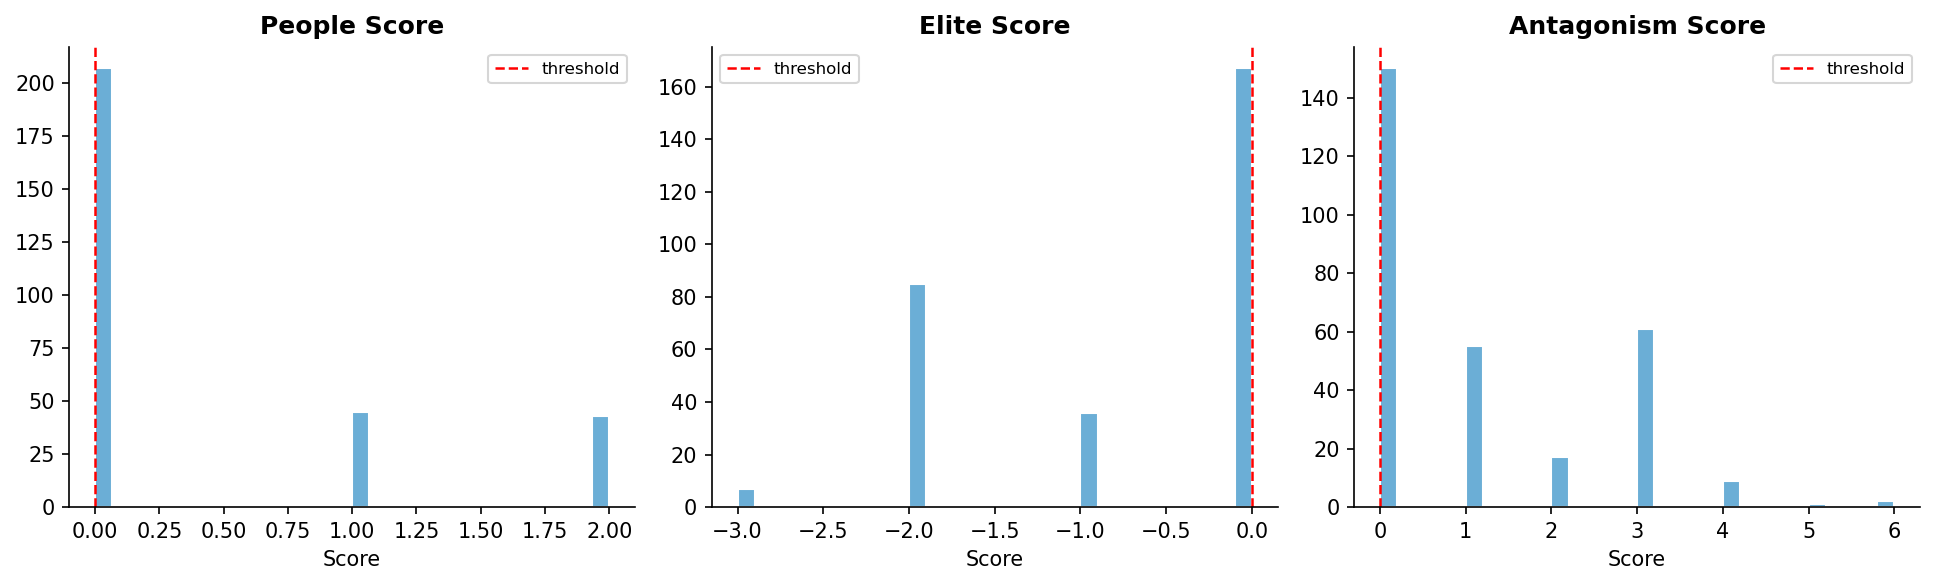


Binarized label counts (n=300):
            Anti-Elitism: 128 positive (42.7%)
         People-Centrism:  88 positive (29.3%)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
    ["people_score_raw", "elite_score_raw", "antagonism_score_raw"],
    ["People Score", "Elite Score", "Antagonism Score"]):
    vals = df_llm[col].dropna()
    ax.hist(vals, bins=30, color="#6baed6", edgecolor="white")
    ax.axvline(0, color="red", ls="--", lw=1.2, label="threshold")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Score")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"\nBinarized label counts (n={len(df_llm)}):")
for dim in LLM_DIMENSIONS:
    n1 = df_llm[dim].sum()
    print(f"  {DISPLAY_NAMES[dim]:>22s}: {int(n1):3d} positive ({100*n1/len(df_llm):.1f}%)")

## 7 — Compute LLM vs. Gold-Standard Metrics (sample-based estimate)

Computed on the 300-text sample with bootstrap 95% CIs.
Only Anti-Elitism and People-Centrism are evaluated (prompt scope).

In [14]:
if 'df_llm' not in dir():
    df_llm = pd.read_csv("llm_predictions.csv")

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95):
    rng = np.random.RandomState(42)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    lo = np.percentile(scores, (1 - ci) / 2 * 100)
    hi = np.percentile(scores, (1 + ci) / 2 * 100)
    return lo, hi


llm_metrics = []

for dim_name in LLM_DIMENSIONS:
    gs  = gold_standard[dim_name]
    llm = df_llm.set_index(ID_COL)[dim_name]

    common = gs.index.intersection(llm.dropna().index)
    y_true = gs.loc[common].astype(int).values
    y_pred = llm.loc[common].astype(int).values

    n = len(common)
    n_pos = int(y_pred.sum())

    f1_val = f1_score(y_true, y_pred, average="binary", zero_division=0)
    kappa  = cohen_kappa_score(y_true, y_pred)
    agree  = np.mean(y_true == y_pred) * 100

    f1_lo, f1_hi = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: f1_score(yt, yp, average="binary", zero_division=0))

    # Pairwise F1: LLM vs. each individual coder
    mat = gold_matrices[dim_name]
    pw_scores = []
    for coder in mat.columns:
        idx = common.intersection(mat[coder].dropna().index)
        if len(idx) > 0:
            pw_scores.append(f1_score(
                mat[coder].loc[idx].astype(int),
                llm.loc[idx].astype(int),
                average="binary", zero_division=0,
            ))
    f1_vs_coders = np.mean(pw_scores) if pw_scores else np.nan

    llm_metrics.append({
        "Label":        DISPLAY_NAMES[dim_name],
        "N":            n,
        "N_pos":        n_pos,
        "kappa":        round(kappa, 3),
        "agree":        round(agree, 2),
        "F1_vs_gold":   round(f1_val, 3),
        "F1_95ci":      f"[{f1_lo:.3f}, {f1_hi:.3f}]",
        "F1_vs_coders": round(f1_vs_coders, 3),
    })

df_metrics = pd.DataFrame(llm_metrics)
df_metrics

,Label,N,N_pos,kappa,agree,F1_vs_gold,F1_95ci,F1_vs_coders
0,Anti-Elitism,295,128,0.261,66.44,0.428,"[0.331, 0.515]",0.426
1,People-Centrism,295,88,0.094,71.86,0.144,"[0.047, 0.242]",0.226


## 8 — Combined Comparison Table

In [15]:
# Expert baseline — only the two dimensions our prompt covers
tbl_expert = popbert_baseline[
    popbert_baseline["Label"].isin(["Anti-Elitism", "People-Centrism"])
].rename(columns={"fleiss_kappa": "κ", "agree": "Agreement %"}).copy()
tbl_expert["Source"] = "Expert Coders"

# LLM results
tbl_llm = df_metrics[["Label", "N", "kappa", "agree", "F1_vs_gold"]].copy()
tbl_llm.columns = ["Label", "N", "κ", "Agreement %", "F1"]
tbl_llm["Source"] = "LLM Prompt (n=500)"

# Add mean rows
rows = []
for tbl in [tbl_expert, tbl_llm]:
    mean_row = pd.DataFrame([{
        "Label": "Mean",
        "N": "",
        "κ": round(tbl["κ"].mean(), 3),
        "Agreement %": round(tbl["Agreement %"].mean(), 2),
        "F1": round(tbl["F1"].mean(), 3),
        "Source": tbl["Source"].iloc[0],
    }])
    rows.append(pd.concat([tbl, mean_row], ignore_index=True))

combined = pd.concat(rows, ignore_index=True)
combined = combined[["Source", "Label", "N", "κ", "Agreement %", "F1"]]
print(combined.to_string(index=False))
combined

            Source           Label    N     κ  Agreement %    F1
     Expert Coders    Anti-Elitism 3236 0.410        65.80 0.496
     Expert Coders People-Centrism 1608 0.244        81.80 0.262
     Expert Coders            Mean      0.327        73.80 0.379
LLM Prompt (n=500)    Anti-Elitism  295 0.261        66.44 0.428
LLM Prompt (n=500) People-Centrism  295 0.094        71.86 0.144
LLM Prompt (n=500)            Mean      0.178        69.15 0.286


,Source,Label,N,κ,Agreement %,F1
0,Expert Coders,Anti-Elitism,3236,0.410,65.80,0.496
1,Expert Coders,People-Centrism,1608,0.244,81.80,0.262
2,Expert Coders,Mean,,0.327,73.80,0.379
3,LLM Prompt (n=500),Anti-Elitism,295,0.261,66.44,0.428
4,LLM Prompt (n=500),People-Centrism,295,0.094,71.86,0.144
5,LLM Prompt (n=500),Mean,,0.178,69.15,0.286


In [16]:
combined.to_latex("comparison_table.tex", index=False, escape=False,
                  float_format="%.3f")
print("Saved: comparison_table3.tex")

Saved: comparison_table3.tex


## 9 — Bar Plot: Expert Coders vs. LLM Prompt

Grouped bar plot for the two dimensions the prompt covers:
Anti-Elitism and People-Centrism.

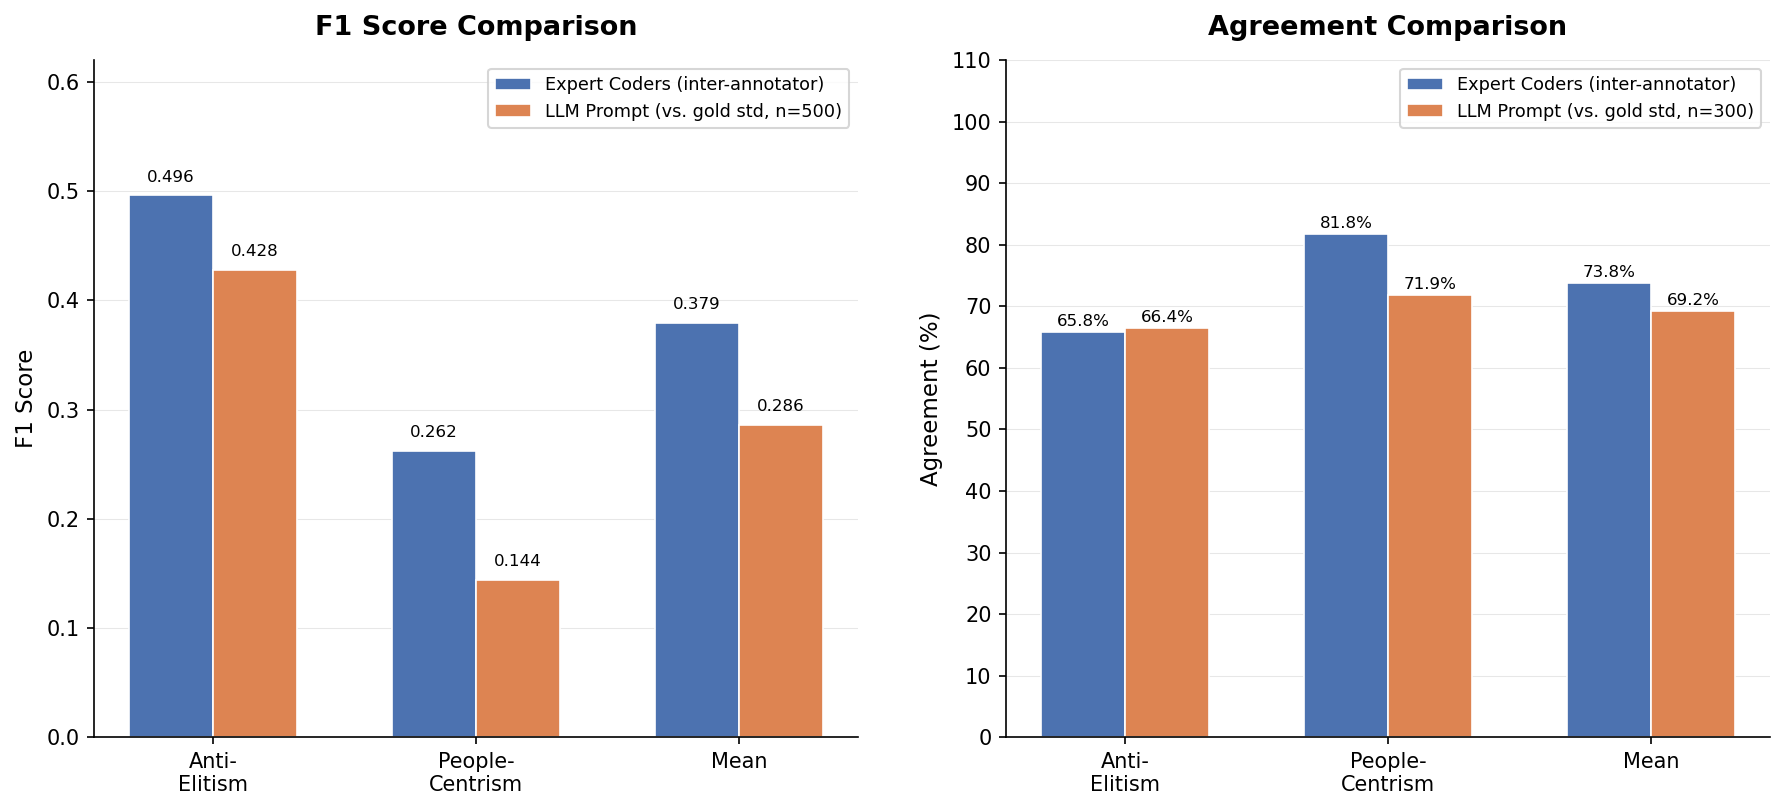

Saved: comparison_barplot.png / .pdf


In [17]:
labels = ["Anti-\nElitism", "People-\nCentrism", "Mean"]

# Expert values (Anti-Elitism, People-Centrism only)
pb = popbert_baseline[popbert_baseline["Label"].isin(
    ["Anti-Elitism", "People-Centrism"])].reset_index(drop=True)
expert_f1    = list(pb["F1"]) + [pb["F1"].mean()]
expert_agree = list(pb["agree"]) + [pb["agree"].mean()]

llm_f1    = list(df_metrics["F1_vs_gold"]) + [df_metrics["F1_vs_gold"].mean()]
llm_agree = list(df_metrics["agree"])      + [df_metrics["agree"].mean()]

x = np.arange(len(labels))
w = 0.32
c_expert = "#4C72B0"
c_llm    = "#DD8452"

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# ── F1 ────────────────────────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w/2, expert_f1, w, label="Expert Coders (inter-annotator)",
            color=c_expert, edgecolor="white", linewidth=0.8)
b2 = ax.bar(x + w/2, llm_f1,    w, label="LLM Prompt (vs. gold std, n=500)",
            color=c_llm, edgecolor="white", linewidth=0.8)
for bg in [b1, b2]:
    for bar in bg:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="medium")
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("F1 Score Comparison", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, max(max(expert_f1), max(llm_f1)) * 1.25)
ax.legend(fontsize=8.5, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.grid(axis="y", alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

# ── Agreement ─────────────────────────────────────────────────────────────
ax = axes[1]
b1 = ax.bar(x - w/2, expert_agree, w, label="Expert Coders (inter-annotator)",
            color=c_expert, edgecolor="white", linewidth=0.8)
b2 = ax.bar(x + w/2, llm_agree,    w, label="LLM Prompt (vs. gold std, n=300)",
            color=c_llm, edgecolor="white", linewidth=0.8)
for bg in [b1, b2]:
    for bar in bg:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                ha="center", va="bottom", fontsize=8, fontweight="medium")
ax.set_ylabel("Agreement (%)", fontsize=11)
ax.set_title("Agreement Comparison", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=8.5, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.grid(axis="y", alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

fig.tight_layout(w_pad=3)
fig.savefig("images/comparison_barplot4.png", bbox_inches="tight")
fig.savefig("images/comparison_barplot4.pdf", bbox_inches="tight")
plt.show()
print("Saved: comparison_barplot.png / .pdf")

## 10 — Bonus: LLM vs. Individual Coders (Pairwise F1)

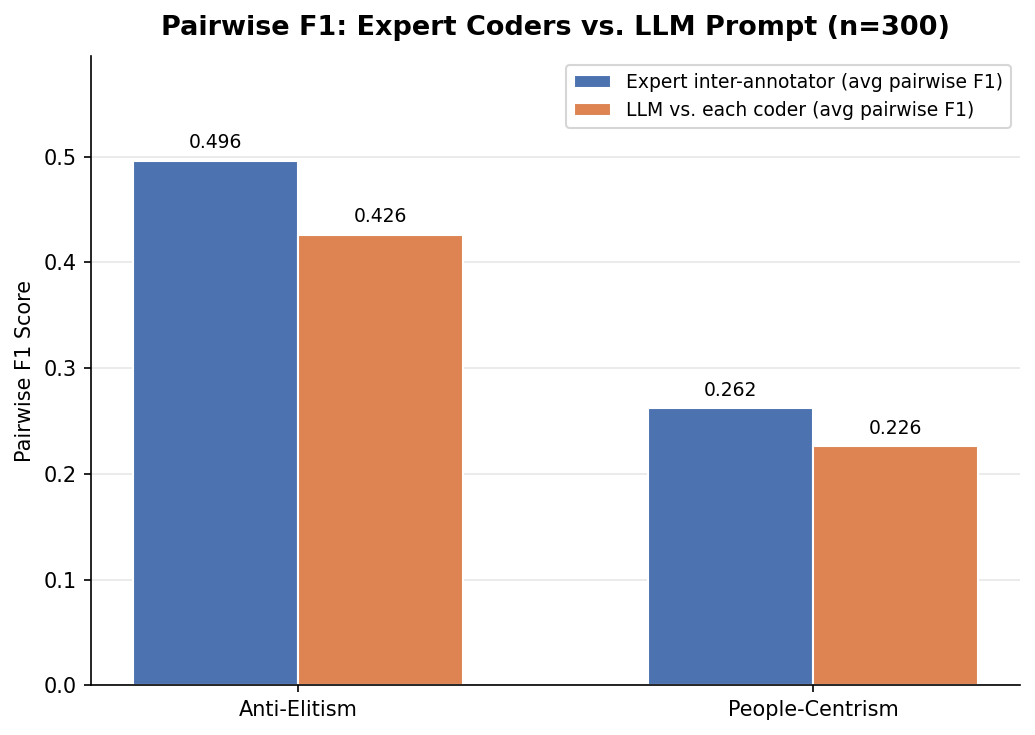

Saved: pairwise_f1_barplot.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

labels_short = [DISPLAY_NAMES[d] for d in LLM_DIMENSIONS]
x = np.arange(len(labels_short))
w = 0.32
c_expert = "#4C72B0"
c_llm    = "#DD8452"

expert_pw = [pb.loc[pb["Label"] == DISPLAY_NAMES[d], "F1"].values[0]
             for d in LLM_DIMENSIONS]
llm_pw    = list(df_metrics["F1_vs_coders"])

b1 = ax.bar(x - w/2, expert_pw, w, label="Expert inter-annotator (avg pairwise F1)",
            color=c_expert, edgecolor="white")
b2 = ax.bar(x + w/2, llm_pw,    w, label="LLM vs. each coder (avg pairwise F1)",
            color=c_llm, edgecolor="white")
for bg in [b1, b2]:
    for bar in bg:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Pairwise F1 Score")
ax.set_title("Pairwise F1: Expert Coders vs. LLM Prompt (n=300)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xticks(x); ax.set_xticklabels(labels_short, fontsize=10)
ax.set_ylim(0, max(max(expert_pw), max(llm_pw)) * 1.2)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("images/pairwise/prompt4-pairwise_f1_barplot4.png", bbox_inches="tight")
plt.show()
print("Saved: pairwise_f1_barplot.png")